# Course 27666 AI-guided Protein Science

# Graph Machine Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Multiomics-Analytics-Group/course_graph_machine_learning/blob/main/notebooks/PyG_introduction.ipynb)

# PyTorch Geometric (PyG) Introduction

## Install PyG

Before we begin, we need to install PyTorch Geometric and its dependencies. PyG is an extension of PyTorch specifically designed to handle irregular data structures like graphs.

In [1]:
# Uncomment and run the following commands if PyG is not installed.
#!pip install torch torch-geometric matplotlib

## 1. Creating a Simple Graph in PyTorch Geometric

In standard deep learning, we use images (grids of pixels) or text (sequences of words). In GML, we use **Graphs**. 

The core `Data` class in PyG represents a single graph using these primary attributes:
* **`x`**: The node feature matrix of shape `[Num_Nodes, Num_Features]`.
* **`edge_index`**: The graph connectivity matrix of shape `[2, Num_Edges]`. It uses Coordinate (COO) format, meaning row 0 contains source nodes and row 1 contains target nodes.
* **`edge_attr`**: Edge feature matrix (optional).
* **`y`**: The labels we want to predict (graph-level or node-level).

In [2]:
import torch
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx, to_networkx
import networkx as nx
import matplotlib.pyplot as plt

# Define node features and edge connections
num_nodes = 4
x = torch.tensor([[1], [2], [3], [4]], dtype=torch.float)  # Node features (4 nodes, 1 feature each)
edge_index = torch.tensor([
    [0, 1, 2, 3],  # Source nodes
    [1, 0, 3, 2]   # Target nodes
], dtype=torch.long)  # Edge list

# Create a PyG Data object
data = Data(x=x, edge_index=edge_index)

print("Graph Information:")
print(data)
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")

Graph Information:
Data(x=[4, 1], edge_index=[2, 4])
Number of nodes: 4
Number of edges: 4


## 2. Converting a NetworkX Graph to PyG

[NetworkX](https://networkx.org/) is a popular Python library for studying complex networks and creating visual plots. However, it is not optimized for GPU-accelerated deep learning. PyG provides seamless utility functions to convert NetworkX graphs into PyG `Data` objects so we can visualize them easily before training.


Converted NetworkX Graph:
Data(edge_index=[2, 8], feature=[4, 1], num_nodes=4, x=[4, 1])


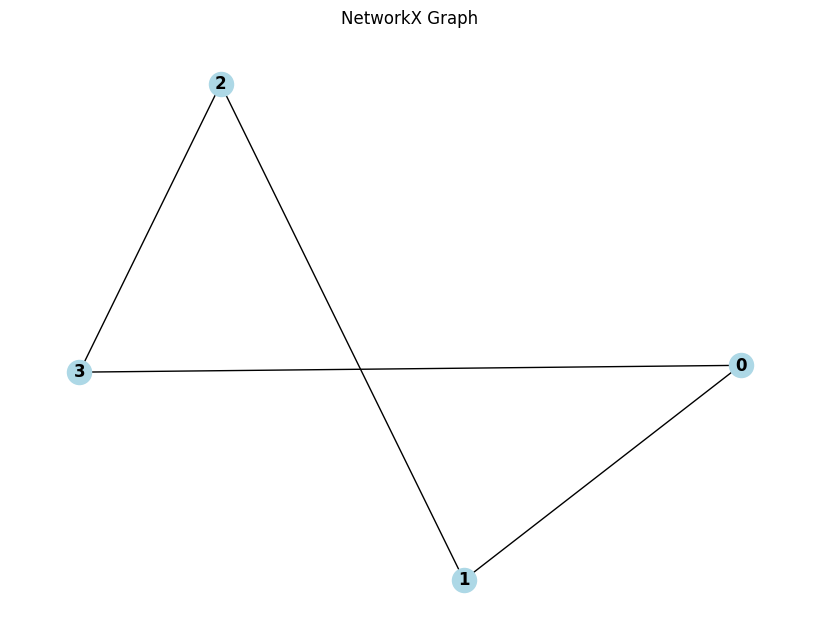

In [3]:
# Create a NetworkX graph
G = nx.Graph()
G.add_nodes_from([
    (0, {"feature": [1.0]}),
    (1, {"feature": [2.0]}),
    (2, {"feature": [3.0]}),
    (3, {"feature": [4.0]})
])
G.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 0)])

# Convert the NetworkX graph to a PyG Data object
data_from_nx = from_networkx(G)
data_from_nx.x = torch.tensor([G.nodes[node]["feature"] for node in G.nodes()], dtype=torch.float)

print("\nConverted NetworkX Graph:")
print(data_from_nx)

# Visualize the NetworkX graph
plt.figure(figsize=(8, 6))
nx.draw(G, with_labels=True, node_color='lightblue', font_weight='bold')
plt.title("NetworkX Graph")
plt.show()

## 3. Loading the PROTEINS Dataset

We are going to use the [TU Dataset](https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.datasets.TUDataset.html), which contains a variety of graph kernel benchmark datasets, .e.g., "IMDB-BINARY", "REDDIT-BINARY" or "PROTEINS", collected from the TU Dortmund University.

* **The Graph:** Nodes represent amino acid residues. Edges indicate that these residues are physically close to one another in 3D space.
* **The Features:** Each node has 3 basic structural features.
* **The Task:** A binary classification task to predict whether the entire protein graph is an Enzyme (catalyst) or a Non-Enzyme.

Enzymes are biological catalysts responsible for accelerating nearly every chemical reaction in living organisms. By training the GNN on this dataset, the AI is learning to recognize the structural "signature" or architectural layout required for catalytic function. This capability is foundational when designing custom synthetic enzymes for green chemistry or industrial waste breakdown.

In [4]:
import torch
from torch_geometric.datasets import TUDataset

# You can swap 'PROTEINS' for 'MUTAG' if you prefer small molecules.
dataset = TUDataset(root='data/PROTEINS', name='PROTEINS')

print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features per node: {dataset.num_features}')
print(f'Number of target classes: {dataset.num_classes}')

# Inspecting the first protein graph structure
data = dataset[0]  
print('\nFirst Graph Structure Information:')
print(data)
print(f'Number of nodes (residues/atoms): {data.num_nodes}')
print(f'Number of edges (bonds/contacts): {data.num_edges}')
print(f'Is undirected: {data.is_undirected()}')

Processing...


Dataset: PROTEINS(1113):
Number of graphs: 1113
Number of features per node: 3
Number of target classes: 2

First Graph Structure Information:
Data(edge_index=[2, 162], x=[42, 3], y=[1])
Number of nodes (residues/atoms): 42
Number of edges (bonds/contacts): 162
Is undirected: True


Done!


## 4. Disjoint Mini-Batching for Graphs

In standard deep learning, data is batched by stacking uniform matrices. Graphs, however, have varying numbers of nodes and edges. PyTorch Geometric solves this by packing a batch of graphs (e.g., 64 proteins) into a single, giant "disjoint" graph.

To prevent different proteins from accidentally passing messages to one another, PyG creates a **`batch` vector**. This vector acts as an index, mapping every individual node in the giant graph back to its original protein graph.

In [5]:
from torch_geometric.loader import DataLoader

# Shuffle the dataset and split (e.g., 80% train, 20% test)
torch.manual_seed(12345)
dataset = dataset.shuffle()

train_split = int(len(dataset) * 0.8)
train_dataset = dataset[:train_split]
test_dataset = dataset[train_split:]

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Number of training graphs: {len(train_dataset)}')
print(f'Number of test graphs: {len(test_dataset)}')

# Let's inspect the first mini-batch
for step, batch in enumerate(train_loader):
    print(f'\nBatch {step + 1}:')
    print('=======')
    print(f'Number of graphs in this batch: {batch.num_graphs}')
    print(batch)
    # Note the 'batch' vector attribute pointing each node to its respective graph index
    print(f'Batch vector shape: {batch.batch.shape}') 
    break

Number of training graphs: 890
Number of test graphs: 223

Batch 1:
Number of graphs in this batch: 64
DataBatch(edge_index=[2, 9268], x=[2464, 3], y=[64], batch=[2464], ptr=[65])
Batch vector shape: torch.Size([2464])


## 5. Defining the Graph Convolutional Network (GCN)


Our model will perform two main operations:
1.  **Spatial Message Passing (`GCNConv`):** Every node looks at its connected neighbors, aggregates their features, and updates its own representation. We stack three layers, allowing nodes to "see" three structural steps away.
2.  **Global Readout (`global_mean_pool`):** Because we want to classify the *entire* protein (not just single atoms), we must compress all node features into a single vector. We do this by taking the mathematical average of all nodes belonging to the same graph.

In [ ]:
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GCNConv, global_mean_pool

class MoleculeProteinGCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(MoleculeProteinGCN, self).__init__()
        torch.manual_seed(12345)
        
        # Message Passing/Graph Convolution Layers
        self.conv1 = GCNConv(dataset.num_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        
        # Final fully connected classifier layer
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain localized node embeddings
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout Layer: Pool node embeddings into unified graph embeddings
        # 'batch' is the vector tracking node assignments per graph batch segment
        x = global_mean_pool(x, batch)  # Output shape: [batch_size, hidden_channels]

        # 3. Apply a final classifier with dropout regularization
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

MoleculeProteinGCN(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)


## 6. Training the Model

We will train the model using standard PyTorch methodology:
1. Pass the batch through the model.
2. Calculate the Cross-Entropy Loss.
3. Backpropagate the gradients.
4. Update the weights using the Adam optimizer.

*Note:* Notice that when we accumulate `total_loss`, we multiply by `data.num_graphs`. This is because PyTorch averages the loss over the batch by default, and we want to keep an accurate running total of the absolute loss to divide by the total dataset size later.

In [ ]:
# Instantiate the model and print its architecture
model = MoleculeProteinGCN(hidden_channels=64)
print(model)

MoleculeProteinGCN(
  (conv1): GCNConv(3, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (lin): Linear(in_features=64, out_features=2, bias=True)
)


In [ ]:
# Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

In [ ]:
# Training and evaluation functions
def train():
    model.train()
    total_loss = 0
    
    for data in train_loader:  # Iterate over batches of graphs
        optimizer.zero_grad()  
        # Pass the data attributes including the batch vector
        out = model(data.x, data.edge_index, data.batch)  
        loss = criterion(out, data.y)  # Calculate loss on graph classification targets
        loss.backward()  
        optimizer.step()  
        total_loss += loss.item() * data.num_graphs
        
    return total_loss / len(train_dataset)

def test(loader):
    model.eval()
    correct = 0
    
    for data in loader:  
        out = model(data.x, data.edge_index, data.batch)  
        pred = out.argmax(dim=-1)  # Class with the highest predicted probability
        correct += int((pred == data.y).sum())  
        
    return correct / len(loader.dataset)

# Train the model for 100 epochs
for epoch in range(1, 101):
    loss = train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 001, Loss: 0.6904, Train Acc: 0.5989, Test Acc: 0.5830
Epoch: 010, Loss: 0.6104, Train Acc: 0.7236, Test Acc: 0.6771
Epoch: 020, Loss: 0.6007, Train Acc: 0.7169, Test Acc: 0.6726
Epoch: 030, Loss: 0.6036, Train Acc: 0.7146, Test Acc: 0.6726
Epoch: 040, Loss: 0.5949, Train Acc: 0.6944, Test Acc: 0.6816
Epoch: 050, Loss: 0.5974, Train Acc: 0.7371, Test Acc: 0.6861
Epoch: 060, Loss: 0.5911, Train Acc: 0.7315, Test Acc: 0.6816
Epoch: 070, Loss: 0.5984, Train Acc: 0.6742, Test Acc: 0.6771
Epoch: 080, Loss: 0.5977, Train Acc: 0.7079, Test Acc: 0.6637
Epoch: 090, Loss: 0.5953, Train Acc: 0.7416, Test Acc: 0.6861
Epoch: 100, Loss: 0.5767, Train Acc: 0.7157, Test Acc: 0.6771


## 7. Evaluating the Model

During training, PyTorch tracks all mathematical operations to calculate gradients. During evaluation, we use the `@torch.no_grad()` decorator to disable this tracking. This saves significant memory and speeds up our metrics calculations.

We will extract the model's predictions and use Scikit-Learn to generate a clean classification report.

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

@torch.no_grad()
def evaluate_graph_model(model, loader):
    """
    Simplified evaluation function for introductory GML.
    Extracts predictions and ground truths to generate a classification report.
    """
    model.eval()
    all_preds = []
    all_targets = []

    for data in loader:
        out = model(data.x, data.edge_index, data.batch)
        preds = out.argmax(dim=-1) # Get the predicted class (0 or 1)
        
        all_preds.append(preds.cpu().numpy())
        all_targets.append(data.y.cpu().numpy())

    # Flatten lists into 1D numpy arrays
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    accuracy = accuracy_score(all_targets, all_preds)
    
    print("\n--- FINAL EVALUATION METRICS ---")
    print(f"Overall Accuracy: {accuracy:.4f}\n")
    
    target_names = ['Non-Enzyme', 'Enzyme']
    print(classification_report(all_targets, all_preds, target_names=target_names))

# Run the evaluation on the unseen test set
evaluate_graph_model(model, test_loader)


================ FINAL EVALUATION METRICS ================
Overall Accuracy:  0.6771
Precision Score:   0.6207 (binary averaged)
Recall (Sens.):    0.5806 (binary averaged)
F1-Score:          0.6000 (binary averaged)
ROC-AUC Score:     0.6903

Class-Specific Performance Details:
              precision    recall  f1-score   support

  Non-Enzyme       0.71      0.75      0.73       130
      Enzyme       0.62      0.58      0.60        93

    accuracy                           0.68       223
   macro avg       0.67      0.66      0.66       223
weighted avg       0.67      0.68      0.68       223



## 8. Visualizing the embeddings

How does the neural network differentiate between Enzymes and Non-Enzymes?

We can extract the numerical vector of each protein right after the `global_mean_pool` layer (before the final classification decision). These vectors exist in a 64-dimensional space. We use a technique called **t-SNE** to squash these 64 dimensions down to 2 dimensions so we can plot them on a scatter graph and visually inspect the model's learned clusters.

Computing t-SNE for 223 full graph embeddings...


/Users/albsad/miniconda3/envs/gml_env/lib/python3.10/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


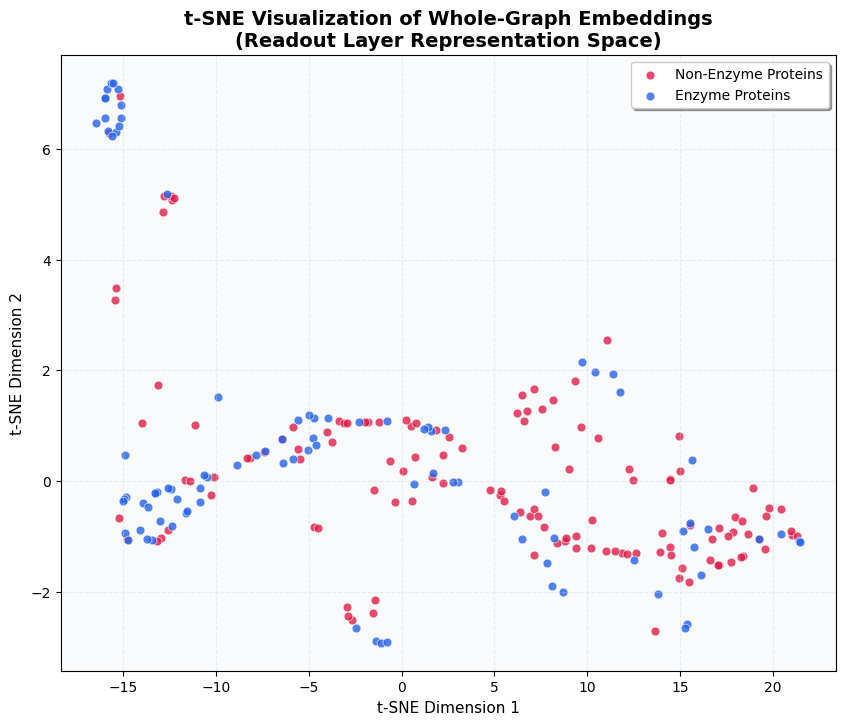

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
from torch_geometric.nn import global_mean_pool

@torch.no_grad()
def visualize_graph_embeddings_simplified(model, loader):
    """
    Extracts graph-level embeddings and plots them in 2D using t-SNE.
    Simplified for introductory learning.
    """
    model.eval()
    embeddings = []
    labels = []

    # ---------------------------------------------------------
    # 1. EXTRACT EMBEDDINGS
    # ---------------------------------------------------------
    for data in loader:
        # Replicate the forward pass up to the pooling layer
        x = model.conv1(data.x, data.edge_index).relu()
        x = model.conv2(x, data.edge_index).relu()
        x = model.conv3(x, data.edge_index)
        
        # Pool node features into a single vector per graph
        graph_emb = global_mean_pool(x, data.batch) 
        
        embeddings.append(graph_emb.cpu().numpy())
        labels.append(data.y.cpu().numpy())

    # Combine batches into single NumPy arrays
    embeddings = np.concatenate(embeddings, axis=0)
    labels = np.concatenate(labels, axis=0)

    print(f"Computing t-SNE for {len(labels)} graphs...")

    # ---------------------------------------------------------
    # 2. REDUCE DIMENSIONS (t-SNE)
    # ---------------------------------------------------------
    # Squash the 64-dimensional embeddings down to 2D for plotting
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    # ---------------------------------------------------------
    # 3. PLOT THE CLUSTERS
    # ---------------------------------------------------------
    plt.figure(figsize=(8, 6))
    
    # Plot Class 0 (Non-Enzymes)
    plt.scatter(
        embeddings_2d[labels == 0, 0], embeddings_2d[labels == 0, 1], 
        label="Non-Enzyme", color="crimson", alpha=0.7, edgecolors='w'
    )
    
    # Plot Class 1 (Enzymes)
    plt.scatter(
        embeddings_2d[labels == 1, 0], embeddings_2d[labels == 1, 1], 
        label="Enzyme", color="royalblue", alpha=0.7, edgecolors='w'
    )

    plt.title("t-SNE Visualization of Protein Graph Embeddings")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Run the visualization on the test dataset
visualize_graph_embeddings_simplified(model, test_loader)

## 8. Visualizing the "Brain" of the AI (t-SNE)

How does the neural network differentiate between Enzymes and Non-Enzymes? 
We can extract the numerical vector of each protein right after the `global_mean_pool` layer (before the final classification decision). These vectors exist in a 64-dimensional space. We use a technique called **t-SNE** to squash these 64 dimensions down to 2 dimensions so we can plot them on a scatter graph and visually inspect the model's learned clusters.